# Basic EDS data fitting in quantEM

Data available [here](https://drive.google.com/file/d/1WbImlBha9t_C38QMk05gwMDHTb2IWFfz/view?usp=sharing)

Tutorial developed by Stephanie Ribet (sribet@lbl.gov) and Sanya Gowda 

Data acquired by Sanya Gowda and Karen Bustillo at NCEM/Molecular Foundry, Lawrence Berkeley National Laboratory

Last updated 30 April 2026

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import quantem as em
from quantem.core import config

config.set_device(1)
print(config.get("device"))

import torch
torch.manual_seed(0)

cuda:1


# load data and inspect data

In [3]:
eds = em.io.read_3d_spectroscopy(
    '/EDS_00.bcf',
    file_type="bruker", data_type="XEDS"
)

Available datasets:
  Dataset 0: shape (236, 244), ndim=2
  Dataset 1: shape (236, 244, 4096), ndim=3
Using first 3D dataset at index 1 with shape (236, 244, 4096). 3D dataset indices: 1


(<Figure size 1200x400 with 3 Axes>,
 (<Axes: title={'center': 'Integrated Intensity Map'}>,
  <Axes: title={'center': 'Spectrum from ROI [0:236, 0:244]'}, xlabel='Energy (keV)', ylabel='Normalized intensity'>))

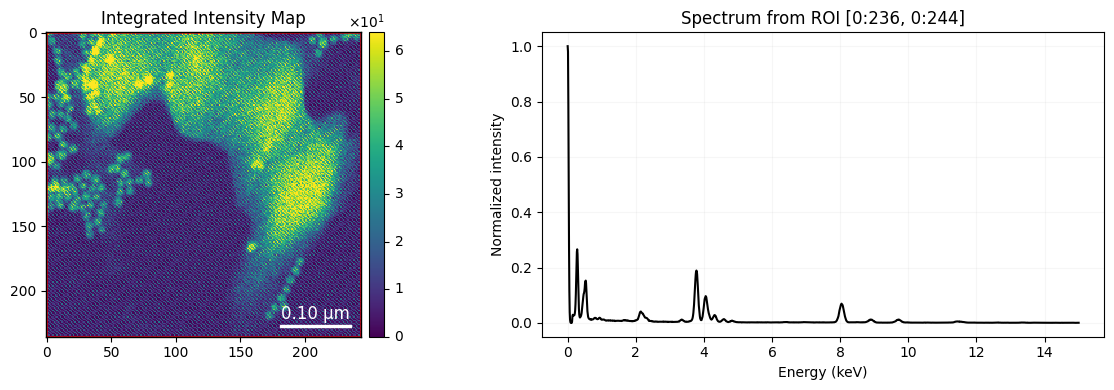

In [4]:
eds.show_mean_spectrum(
    energy_range=[0, 15],
    normalize = True
)


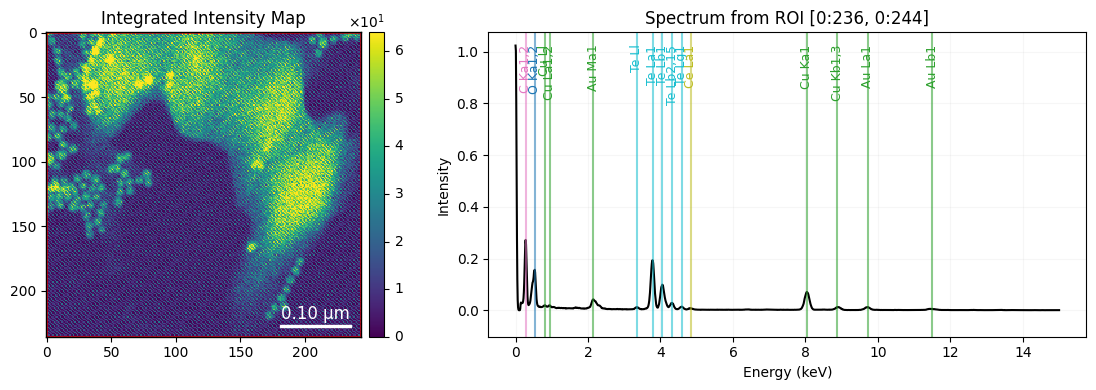

Energy (keV) Intensity    SNR      Best Match               Alt 2                    Alt 3                   
----------------------------------------------------------------------------------------------------------------
0.280        0.27         35.4     C Ka1,2 (0.277)          B Ka1,2 (0.183)          N Ka1,2 (0.392)         
0.530        0.16         20.4     O Ka1,2 (0.525)          V La1,2 (0.511)          Cr La1,2 (0.573)        
0.810        0.02         2.5      Cu Ll (0.811)            Cu La1,2 (0.930)         Cu Lb1 (0.950)          
0.940        0.02         2.5      Cu La1,2 (0.930)         Cu Lb1 (0.950)           Cu Ll (0.811)           
2.150        0.04         5.5      Au Ma1 (2.123)           Hg Ma1 (2.195)           Nb La1 (2.166)          
3.340        0.01         1.6      Te Ll (3.336)            K Ka1 (3.314)            In La1 (3.287)          
3.780        0.19         25.2     Te La1 (3.769)           Te La2 (3.759)           Sb Lb1 (3.844)          
4.050  

(<Figure size 1200x400 with 3 Axes>,
 (<Axes: title={'center': 'Integrated Intensity Map'}>,
  <Axes: title={'center': 'Spectrum from ROI [0:236, 0:244]'}, xlabel='Energy (keV)', ylabel='Intensity'>))

In [6]:
# solve for elements in spectrum
eds.peak_autoid(
    elements = ["Te", "Au", "C", "O", "Cu",],
    mode = "elements_preferred",
    energy_range=[0, 15],
    # roi = [100, 0, 50, 50]
)


# generate spectrum images

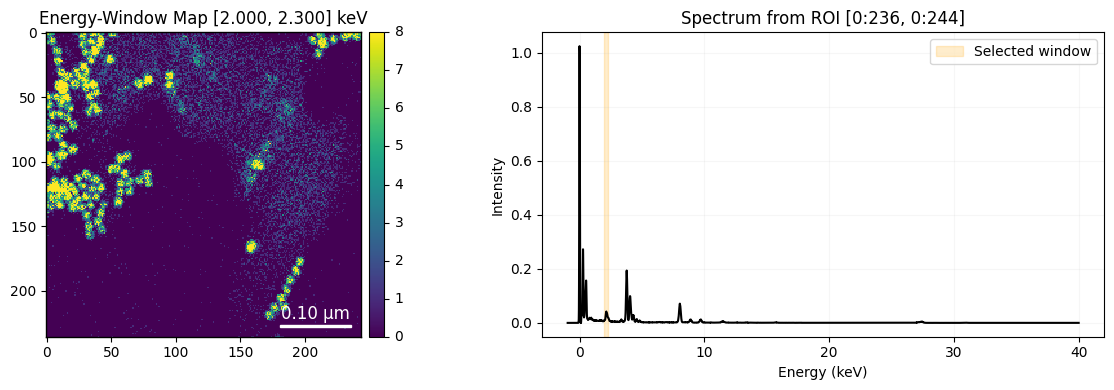

(<Figure size 1200x400 with 3 Axes>,
 (<Axes: title={'center': 'Energy-Window Map [2.000, 2.300] keV'}>,
  <Axes: title={'center': 'Spectrum from ROI [0:236, 0:244]'}, xlabel='Energy (keV)', ylabel='Intensity'>),
 array([[ 2.,  1., 10., ...,  3.,  2.,  0.],
        [ 4.,  7.,  5., ...,  8.,  6.,  6.],
        [ 5.,  4.,  4., ...,  5.,  4.,  6.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(236, 244)))

In [7]:
eds.show_energy_window_map(
    energy_window = (2.0, 2.3)
)

In [8]:
eds.add_elements_to_model(
    ["Te", "Au", "C", "O", "Cu"]
)

Added to model:
 - Au: Ka1, Ka2, Kb1, Kb2, Kb3, La1, La2, Lb1, Lb2, Lg1, Ll, Ma1
 - C: Ka1,2
 - Cu: Ka1, Ka2, Kb1,3, La1,2, Lb1, Ll
 - O: Ka1,2
 - Te: Ka1, Ka2, Kb1, Kb2, Kb3, La1, La2, Lb1, Lb2,15, Lg1, Ll


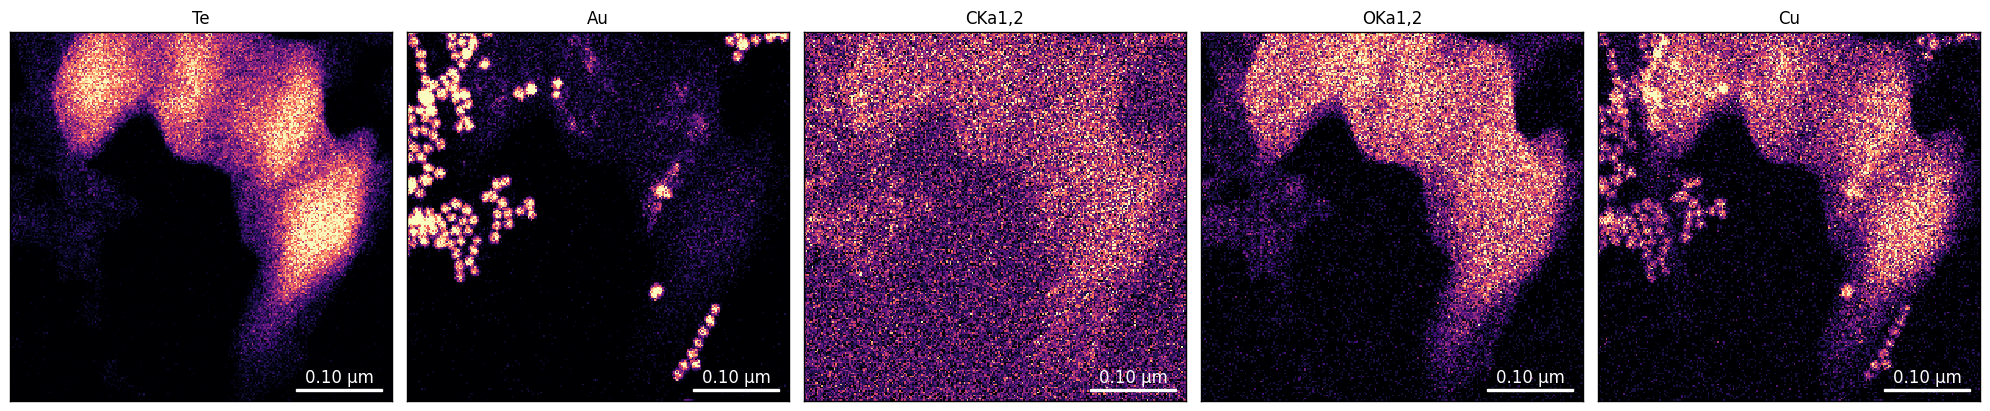

In [10]:
spectrum_images = eds.generate_spectrum_images(return_maps=True)

# fit

fitting spectrum globally
Fitting 5 elements with 19 total peaks across 7 edge groups
iter    1/50: loss=0.0139498
iter    5/50: loss=0.0060987
iter   10/50: loss=0.00159252
iter   15/50: loss=0.000436694
iter   20/50: loss=0.000431034
iter   25/50: loss=0.00043067
iter   30/50: loss=0.00043067
iter   35/50: loss=0.00043067
iter   40/50: loss=0.00043067
iter   45/50: loss=0.00043067
iter   50/50: loss=0.00043067

Final: width median=0.126 keV, min=0.064, max=0.215

Top elements:
 1. Te: 15.300
 2. C : 6.480
 3. O : 5.935
 4. Cu: 5.127
 5. Au: 3.109


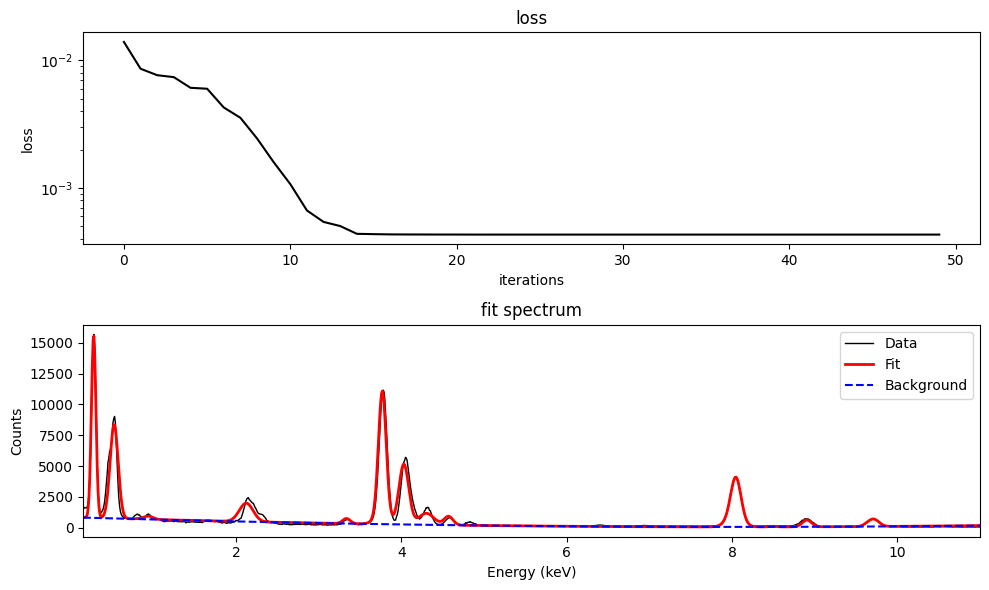

In [11]:

fit = eds.fit_spectrum_pytorch(
    elements_to_fit=["Te", "Au", "Cu", "O", "C", ],
    num_iters=50,
    energy_range=[0.15,11],
    optimizer_global="lbfgs",
    fit_mean_only = True,
    lr_global = 1e-2,
    polynomial_background_degree = 2,
)

fitting spectrum globally
Fitting 5 elements with 18 total peaks across 7 edge groups
iter    1/5000: loss=0.190935
iter  500/5000: loss=0.167732
iter 1000/5000: loss=0.164272
iter 1500/5000: loss=0.16153
iter 2000/5000: loss=0.159182
iter 2500/5000: loss=0.157181
iter 3000/5000: loss=0.155482
iter 3500/5000: loss=0.154038
iter 4000/5000: loss=0.152808
iter 4500/5000: loss=0.151755
iter 5000/5000: loss=0.150849
fitting spectrum position-by-position
iter    1/3000: loss=0.139965
iter  300/3000: loss=0.130848
iter  600/3000: loss=0.126986
iter  900/3000: loss=0.125584
iter 1200/3000: loss=0.125014
iter 1500/3000: loss=0.124329
iter 1800/3000: loss=0.123927
iter 2100/3000: loss=0.123614
iter 2400/3000: loss=0.123393
iter 2700/3000: loss=0.123224
iter 3000/3000: loss=0.123164


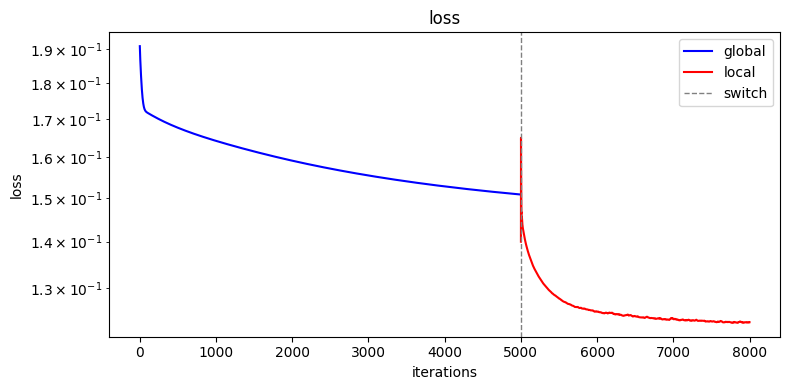

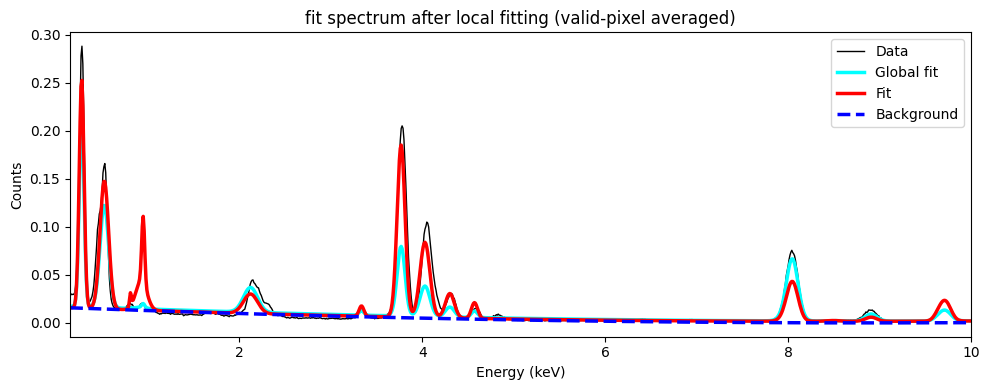

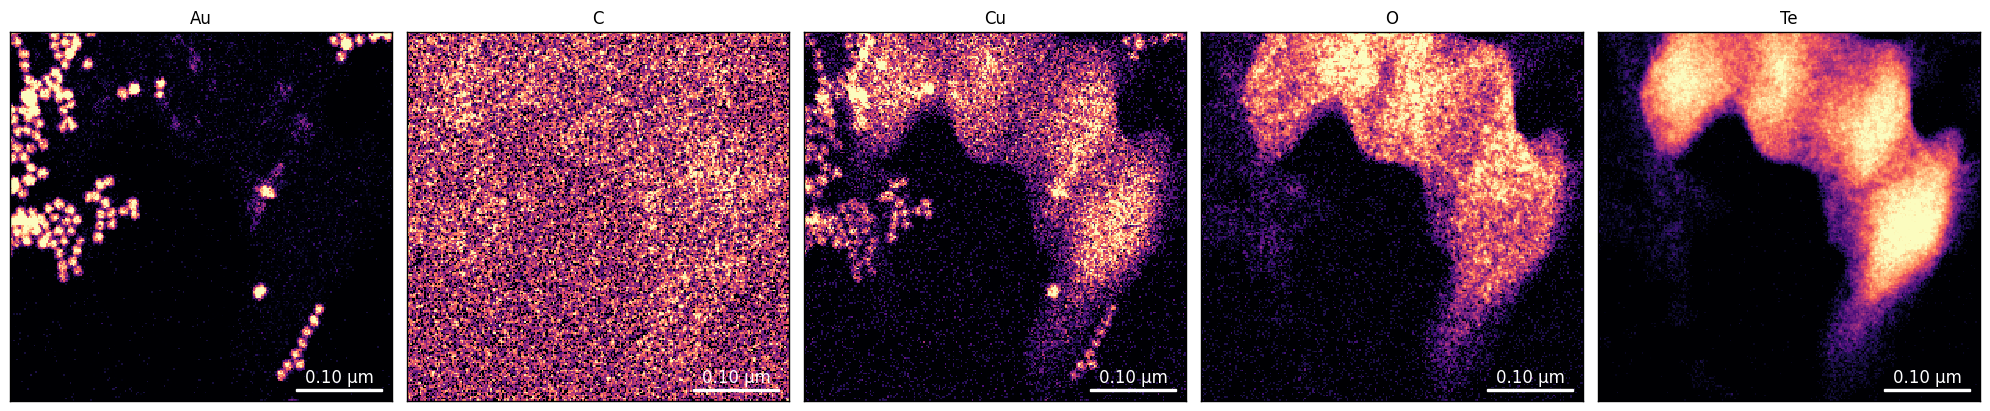

In [12]:
fit = eds.fit_spectrum_pytorch(
    energy_range=(0.15, 10),
    elements_to_fit=["Te", "Au", "Cu", "O", "C", ],
    num_iters_global=5000,
    optimizer_global="adam",
    lr_global = 1e-3,
    num_iters=3000,
    optimizer_local= "adam", 
    polynomial_background_degree=2,
    lr_local = 5e-3,
    freeze_peak_width=True,
    spatial_lambda=1e-4,
    min_total_counts= 1,
    device = "cuda",
    constrain_background=0.1,
)

# compare integrated to fit spectrum images

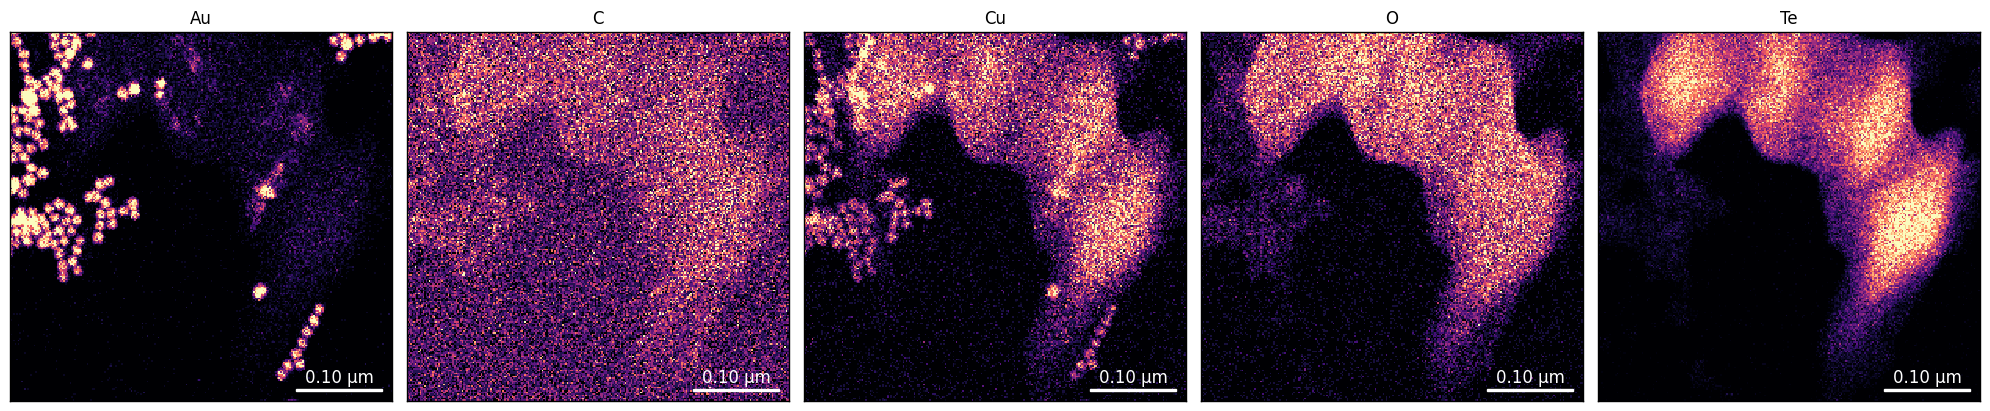

In [13]:
eds.show_spectrum_images()

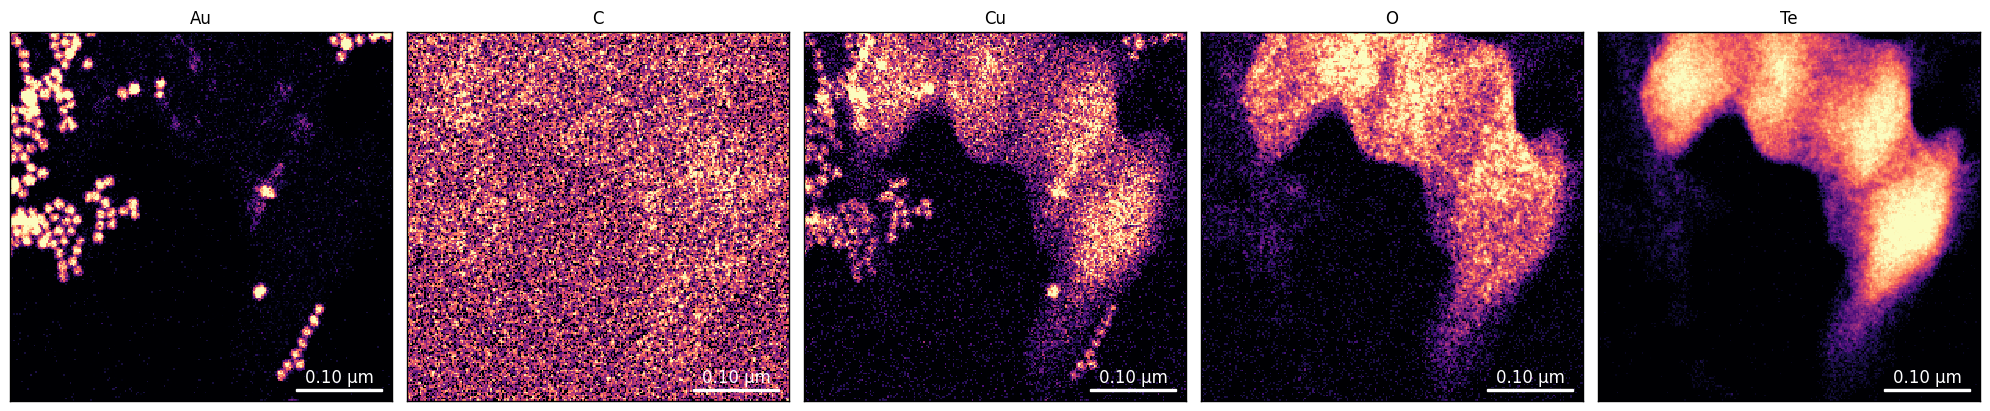

In [14]:
eds.show_spectrum_images(method = "fit")

# PCA

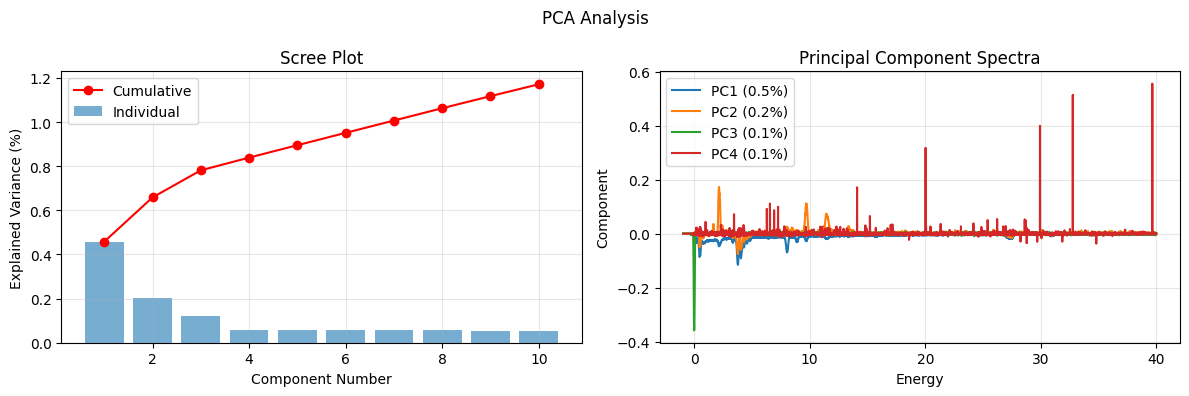

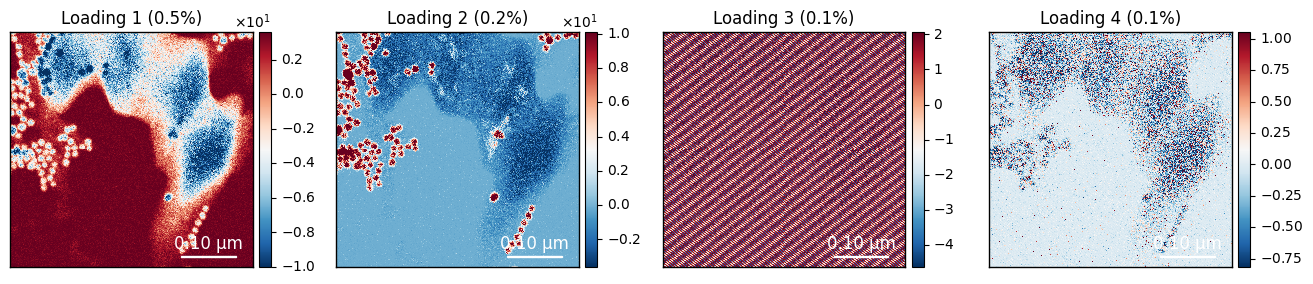

In [15]:
eds.perform_pca(
    # standardize=False,
    # n_components=6
)